In [1]:
import json

# Читаем исходный файл
with open('backup.json', 'r') as file:
    data = json.load(file)

# Обрабатываем данные
for item in data:
    # Преобразуем initial_buy
    if isinstance(item['initial_buy'], str):
        item['initial_buy'] = float(item['initial_buy'].replace(' SOL', ''))
    
    # Преобразуем market_cap
    if isinstance(item['market_cap'], str):
        item['market_cap'] = float(item['market_cap'].replace(' SOL', ''))

# Сохраняем в новый файл
with open('backup_cleared.json', 'w') as file:
    json.dump(data, file, indent=4)

In [2]:
import pandas as pd
import json

# Чтение JSON
with open("backup_cleared.json", "r") as f:
    data = json.load(f)

# Преобразование в DataFrame
df = pd.DataFrame(data)
df["target"] = (df["result"] >= 0.0).astype(int)  # 1 если прибыль/безубыток

# Сохранение в CSV
df[["initial_buy", "market_cap", "price", "sol_amount", "target"]].to_csv("trades.csv", index=False)

In [3]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import precision_score, roc_auc_score
import pandas as pd

df = pd.read_csv("trades.csv")
X = df[["initial_buy", "market_cap", "price", "sol_amount"]]
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
rf = RandomForestClassifier(n_estimators=1000, max_depth=10, class_weight="balanced", random_state=42)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
print("Precision:", precision_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_pred))
print("Feature Importance:", pd.Series(rf.feature_importances_, index=X.columns))

Precision: 0.45325779036827196
ROC-AUC: 0.7283044058744994
Feature Importance: initial_buy    0.336730
market_cap     0.340779
price          0.000192
sol_amount     0.322298
dtype: float64


In [43]:
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, roc_auc_score
import pandas as pd

# Данные
df = pd.read_csv("trades.csv")

# Downsampling: балансируем датасет
df_pos = df[df["target"] == 1]
df_neg = df[df["target"] == 0].sample(len(df_pos), random_state=42)
df_balanced = pd.concat([df_pos, df_neg])

# Обучающая выборка из сбалансированных
X_train = df_balanced[["initial_buy", "market_cap", "price", "sol_amount"]]
y_train = df_balanced["target"]

# Тестовая выборка — на реальных данных
X_test = df[["initial_buy", "market_cap", "price", "sol_amount"]]
y_test = df["target"]

# Модель
model = CatBoostClassifier(
    iterations=1000,
    max_depth=6,
    learning_rate=0.1,
    verbose=0,
    random_state=42
)
model.fit(X_train, y_train)

# Порог
probas = model.predict_proba(X_test)[:, 1]
y_pred = (probas >= 0.6).astype(int)

# Метрики
print("Precision:", precision_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, probas))
print("Feature Importance:", pd.Series(model.get_feature_importance(), index=X_train.columns))

print("---------------------------------------")

# Sweep по порогам
for threshold in [0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]:
    y_pred = (probas >= threshold).astype(int)
    print(f"Threshold: {threshold}, Precision: {precision_score(y_test, y_pred)}")


Precision: 0.6095744680851064
ROC-AUC: 0.8052222121478201
Feature Importance: initial_buy    30.528974
market_cap     28.057024
price          19.688521
sol_amount     21.725481
dtype: float64
---------------------------------------
Threshold: 0.2, Precision: 0.2605801236329054
Threshold: 0.3, Precision: 0.3546361285555966
Threshold: 0.4, Precision: 0.38914993592481845
Threshold: 0.5, Precision: 0.5363924050632911
Threshold: 0.6, Precision: 0.6095744680851064
Threshold: 0.7, Precision: 0.6496350364963503
Threshold: 0.8, Precision: 0.7009063444108762
Threshold: 0.9, Precision: 0.7665094339622641


In [76]:
from catboost import CatBoostClassifier
from sklearn.metrics import precision_score, roc_auc_score
import pandas as pd

# Данные
df = pd.read_csv("trades.csv")

X_train = df[["initial_buy", "market_cap", "price", "sol_amount"]]
y_train = df["target"]

# Подсчет веса классов вручную
class_counts = y_train.value_counts()
total = len(y_train)
weights = {
    0: total / class_counts[0],
    1: total / class_counts[1]
}

# Модель
model = CatBoostClassifier(
    iterations=1000,
    max_depth=6,
    learning_rate=0.1,
    verbose=0,
    random_state=42,
    class_weights=[weights[0], weights[1]]
)
model.fit(X_train, y_train)

# Предсказания
probas = model.predict_proba(X_train)[:, 1]
y_pred = (probas >= 0.6).astype(int)

# Метрики
print("Precision:", precision_score(y_train, y_pred))
print("ROC-AUC:", roc_auc_score(y_train, probas))
print("Feature Importance:", pd.Series(model.get_feature_importance(), index=X_train.columns))

print("---------------------------------------")

for threshold in [0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]:
    y_pred = (probas >= threshold).astype(int)
    print(f"Threshold: {threshold}, Precision: {precision_score(y_train, y_pred)}")


Precision: 0.5973904939422181
ROC-AUC: 0.8176618452699091
Feature Importance: initial_buy    23.891264
market_cap     29.068744
price          22.269232
sol_amount     24.770761
dtype: float64
---------------------------------------
Threshold: 0.2, Precision: 0.25977390485162505
Threshold: 0.3, Precision: 0.36533333333333334
Threshold: 0.4, Precision: 0.40584269662921346
Threshold: 0.5, Precision: 0.4550438596491228
Threshold: 0.6, Precision: 0.5973904939422181
Threshold: 0.7, Precision: 0.7117241379310345
Threshold: 0.8, Precision: 0.7887596899224806
Threshold: 0.9, Precision: 0.889273356401384


In [42]:
###TESTCR
from catboost import CatBoostClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import precision_score, roc_auc_score
import pandas as pd
import numpy as np

# Данные
df = pd.read_csv("trades.csv")
X = df[["initial_buy", "market_cap", "price", "sol_amount"]]
y = df["target"]

# Downsampling: балансируем датасет
df_pos = df[df["target"] == 1]
df_neg = df[df["target"] == 0].sample(len(df_pos), random_state=23)
df_balanced = pd.concat([df_pos, df_neg])

# Сбалансированные данные для обучения
X_balanced = df_balanced[["initial_buy", "market_cap", "price", "sol_amount"]]
y_balanced = df_balanced["target"]

# Модель
model = CatBoostClassifier(
    iterations=1000,
    max_depth=6,
    learning_rate=0.1,
    verbose=0,
    random_state=42
)

# Кросс-валидация вручную
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
precision_scores = []
roc_auc_scores = []

for train_idx, val_idx in cv.split(X_balanced, y_balanced):
    X_train, X_val = X_balanced.iloc[train_idx], X_balanced.iloc[val_idx]
    y_train, y_val = y_balanced.iloc[train_idx], y_balanced.iloc[val_idx]
    
    model.fit(X_train, y_train)
    probas = model.predict_proba(X_val)[:, 1]
    
    y_pred = (probas >= 0.75).astype(int)
    
    precision_scores.append(precision_score(y_val, y_pred))
    roc_auc_scores.append(roc_auc_score(y_val, probas))

print("Cross-validated Precision:", np.mean(precision_scores))
print("Cross-validated ROC-AUC:", np.mean(roc_auc_scores))

Cross-validated Precision: 0.8622219318737552
Cross-validated ROC-AUC: 0.7516342474489794


In [132]:
from catboost import CatBoostClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import precision_score, roc_auc_score
import pandas as pd
import numpy as np

# Данные
df = pd.read_csv("trades.csv")
X = df[["initial_buy", "market_cap", "price", "sol_amount"]]
y = df["target"]

# Подсчет весов классов вручную
class_counts = y.value_counts()
total = len(y)
weights = {
    0: total / class_counts[0],
    1: total / class_counts[1]
}

# Модель с учетом веса классов
model = CatBoostClassifier(
    iterations=1000,
    max_depth=6,
    learning_rate=0.1,
    verbose=0,
    random_state=42,
    class_weights=[weights[0], weights[1]]
)

# Кросс-валидация
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
precision_scores = []
roc_auc_scores = []

for train_idx, val_idx in cv.split(X, y):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
    
    model.fit(X_train, y_train)
    probas = model.predict_proba(X_val)[:, 1]
    
    y_pred = (probas >= 0.75).astype(int)
    
    precision_scores.append(precision_score(y_val, y_pred))
    roc_auc_scores.append(roc_auc_score(y_val, probas))

print("Cross-validated Precision:", np.mean(precision_scores))
print("Cross-validated ROC-AUC:", np.mean(roc_auc_scores))


Cross-validated Precision: 0.6825087117841614
Cross-validated ROC-AUC: 0.7654036303880091


In [117]:
###TESTPNL

from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np
import json

# Загрузка данных
with open("backup_cleared.json", "r") as f:
    data = json.load(f)
df = pd.DataFrame(data)
df["target"] = (df["result"] >= 0.005).astype(int)

# Сплитим оригинальные данные
df_train, df_test = train_test_split(df, test_size=0.2, stratify=df["target"], random_state=42)

# Балансируем обучающую выборку
df_pos = df_train[df_train["target"] == 1]
df_neg = df_train[df_train["target"] == 0].sample(len(df_pos), random_state=42)
df_bal = pd.concat([df_pos, df_neg])

# Подготовка X/y
features = ["initial_buy", "market_cap", "price", "sol_amount"]
X_train, y_train = df_bal[features], df_bal["target"]
X_test, y_test = df_test[features], df_test["target"]
results_test = df_test["result"]

# Обучаем
model = CatBoostClassifier(
    iterations=2000,
    max_depth=6,
    learning_rate=0.1,
    verbose=0,
    random_state=42
)
model.fit(X_train, y_train)

# Предсказания и PnL
probas = model.predict_proba(X_test)[:, 1]
y_pred = (probas >= 0.7).astype(int)

pnl = results_test[y_pred == 1]
print("Predicted as profitable trades:", len(pnl))
print("Sum:", sum(pnl))
print("Mean PnL per predicted=1:", pnl.mean())
print("All PnLs:\n", pnl.tolist())


Predicted as profitable trades: 146
Sum: 14.613119953102807
Mean PnL per predicted=1: 0.10008986269248502
All PnLs:
 [-0.07473922866376265, 0.13883256499502677, 8.059204154450198, 0.8968055804183188, -0.011725159557649236, -0.00468296480898787, -0.10212636949443474, 0.00012454421142712522, -0.08747895272604493, -0.04153240623127239, -0.10856867380957143, -0.05130580463153181, -0.07236650523189907, -0.012874276548222081, 0.019199917852667128, 0.09633193933699957, 0.7374574707957042, -0.00780783990384283, 1.283480268612905, 0.00012544181592441647, -0.01103907593747975, 0.0001271439012786541, 0.13702921853482322, -0.001194717352238413, -0.10605545146992106, 0.07703081370685286, 0.0184382021371719, 0.06921171283104206, 0.01763798216769459, -0.10833896143118744, -0.061561674579867616, 0.13083407128950922, -0.07460063760140528, 1.4919711817647912, -0.0880904653284142, 1.4625460230066603, -0.02614259956762129, 6.637237643895753e-08, -6.599663396604009e-07, 0.0019765473175435855, -0.0776080372

#### 

In [16]:
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np
import json

# Загрузка данных
with open("backup_cleared.json", "r") as f:
    data = json.load(f)
df = pd.DataFrame(data)
df["target"] = (df["result"] >= 0.3).astype(int)

# Трейн/тест сплит
df_train, df_test = train_test_split(df, test_size=0.2, stratify=df["target"], random_state=12)

# Подсчет весов классов по всей трейновой выборке
class_counts = df_train["target"].value_counts()
total = len(df_train)
weights = {
    0: total / class_counts[0],
    1: total / class_counts[1]
}

# Подготовка X/y
features = ["initial_buy", "market_cap", "price", "sol_amount"]
X_train, y_train = df_train[features], df_train["target"]
X_test, y_test = df_test[features], df_test["target"]
results_test = df_test["result"]

# Обучение с class_weights
model = CatBoostClassifier(
    iterations=1000,
    max_depth=6,
    learning_rate=0.1,
    verbose=0,
    random_state=42,
    class_weights=[weights[0], weights[1]]
)
model.fit(X_train, y_train)

# Предсказания и PnL
probas = model.predict_proba(X_test)[:, 1]
y_pred = (probas >= 0.7).astype(int)

pnl = results_test[y_pred == 1]
print("Predicted as profitable trades:", len(pnl))
print("Sum:", sum(pnl))
print("Mean PnL per predicted=1:", pnl.mean())
print("All PnLs:\n", pnl.tolist())


Predicted as profitable trades: 100
Sum: 26.456929956974726
Mean PnL per predicted=1: 0.2645692995697474
All PnLs:
 [-0.11595706965321646, -0.11272810918408936, -0.047112056888137965, -0.12059476980543275, -0.12098452202658043, -0.07369171975844001, -0.11980310040209292, -0.2101599786091195, -0.12047434741902428, -0.12080952078546395, -0.1210936980300886, -0.11811262003955801, -0.07462418709464308, -0.12060412168844213, -0.11974178727587312, 1.7720260450084095, -0.11453870309255464, -0.12098452483705592, -0.22141131196189556, 0.09872436641269967, -0.12109374935546707, 8.059204154450198, -0.08229541193679596, -0.12084304655476132, -0.26521482010875197, -0.12073997098984322, -0.1210937496777344, -0.12059441633433868, -0.07760803722065589, -0.07091865663023199, -0.1210937494140607, -0.12096747354996011, -0.12075734164866783, 0.019199917852667128, -0.08345937369124129, 1.4453784538087118, -0.117748377101608, -0.26360308039181257, -0.0329725565139084, -0.11599237912895828, -0.07462424435258

In [17]:
# Сохраняем модель
model.save_model("catboost_model_balanced.cbm")


KeyError: 'target'

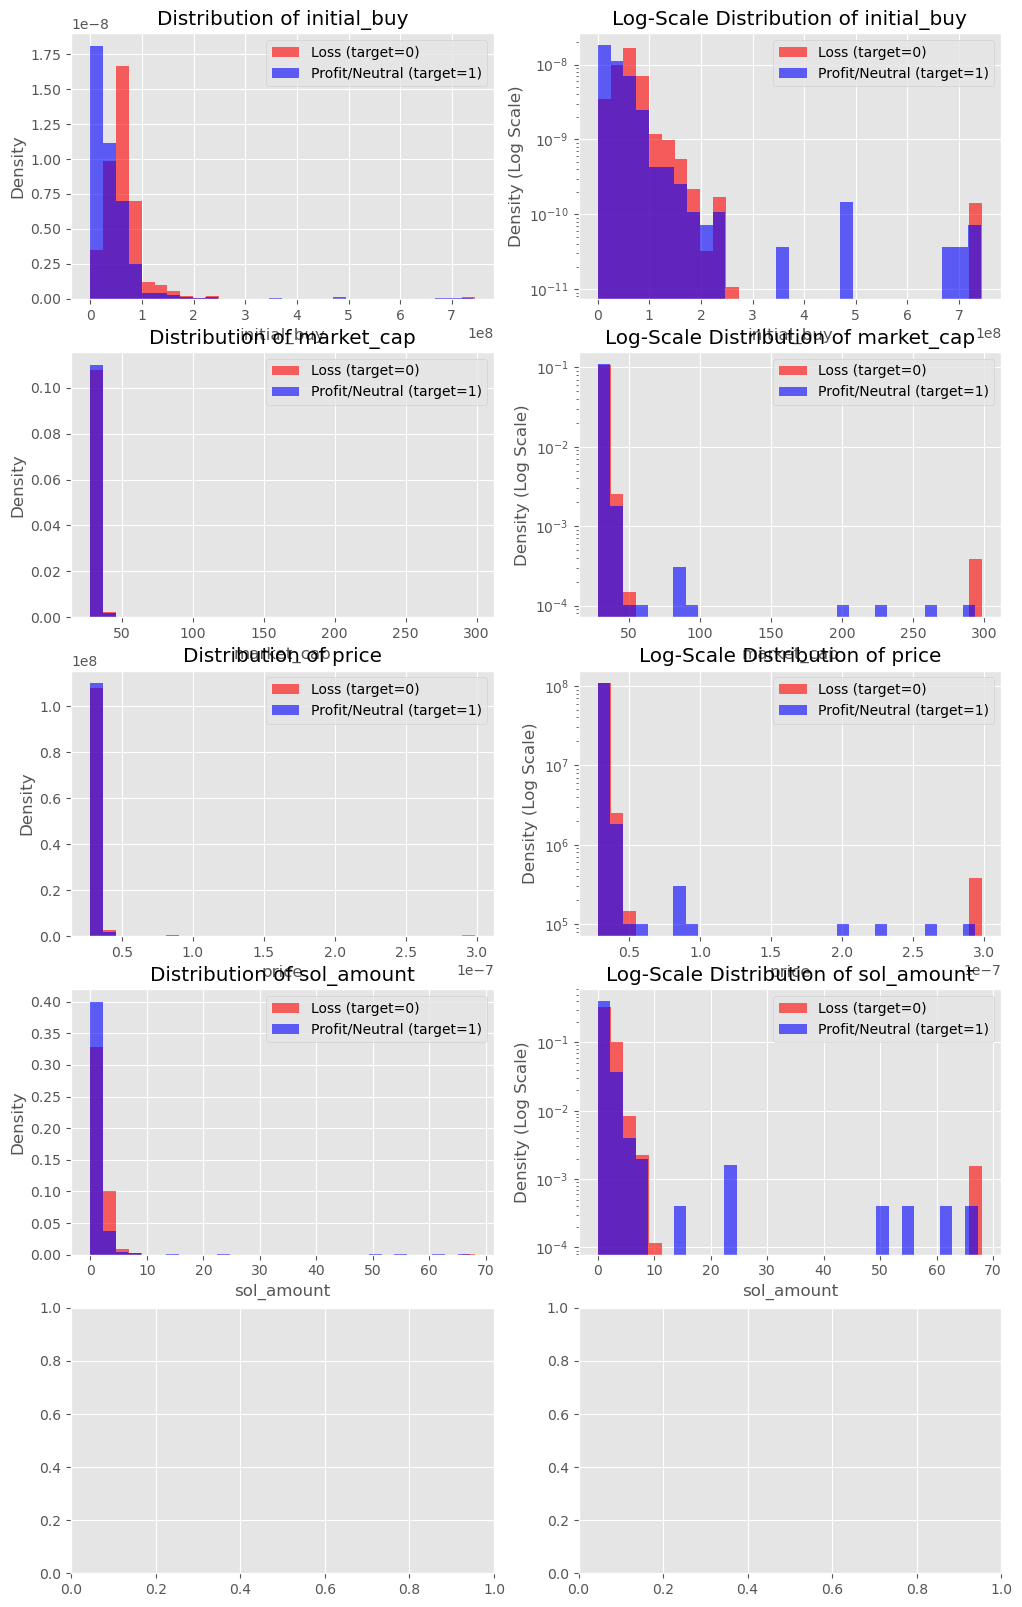

In [111]:
import pandas as pd
import json
import matplotlib.pyplot as plt
import seaborn as sns  # Если установлен Seaborn

# Чтение JSON
with open("backup_cleared.json", "r") as f:
    data = json.load(f)

# Преобразование в DataFrame
df = pd.DataFrame(data)
df["target"] = (df["result"] >= 0.0).astype(int)  # 1 если прибыль/безубыток

# Сохранение в CSV
df[["initial_buy", "market_cap", "price", "sol_amount", "target"]].to_csv("trades.csv", index=False)

# Загрузка данных
df = pd.read_csv("trades.csv")
df_json = pd.DataFrame(data)  # Для result из JSON

# Параметры для визуализации
features = ["initial_buy", "market_cap", "price", "sol_amount", "result"]
colors = {0: "red", 1: "blue"}  # Цвета для target=0 и target=1
labels = {0: "Loss (target=0)", 1: "Profit/Neutral (target=1)"}

# Настройка стиля
plt.style.use("ggplot")  # Используем встроенный стиль Matplotlib
# Если установлен Seaborn, можно использовать:
# sns.set_style("whitegrid")

# Создание сетки графиков
fig, axes = plt.subplots(nrows=len(features), ncols=2, figsize=(12, 4 * len(features)))

# Построение гистограмм
for i, feature in enumerate(features):
    # Используем df_json для result, иначе df
    data_source = df_json if feature == "result" else df
    
    # Гистограмма для target=0
    axes[i, 0].hist(
        data_source[data_source["target"] == 0][feature],
        bins=30,
        color=colors[0],
        alpha=0.6,
        label=labels[0],
        density=True
    )
    # Гистограмма для target=1
    axes[i, 0].hist(
        data_source[data_source["target"] == 1][feature],
        bins=30,
        color=colors[1],
        alpha=0.6,
        label=labels[1],
        density=True
    )
    axes[i, 0].set_title(f"Distribution of {feature}")
    axes[i, 0].set_xlabel(feature)
    axes[i, 0].set_ylabel("Density")
    axes[i, 0].legend()

    # Логарифмическая шкала
    axes[i, 1].hist(
        data_source[data_source["target"] == 0][feature],
        bins=30,
        color=colors[0],
        alpha=0.6,
        label=labels[0],
        density=True,
        log=True
    )
    axes[i, 1].hist(
        data_source[data_source["target"] == 1][feature],
        bins=30,
        color=colors[1],
        alpha=0.6,
        label=labels[1],
        density=True,
        log=True
    )
    axes[i, 1].set_title(f"Log-Scale Distribution of {feature}")
    axes[i, 1].set_xlabel(feature)
    axes[i, 1].set_ylabel("Density (Log Scale)")
    axes[i, 1].legend()

# Установка компактного расположения
plt.tight_layout()
plt.savefig("distributions.png", dpi=300, bbox_inches="tight")  # Сохранение графика
plt.show()

# Статистика по околонулевым result
okolonul = df_json[df_json["result"].between(-0.05, 0.05)]
print(f"Околонулевые трейды (-0.05 ≤ result ≤ 0.05): {len(okolonul)} ({len(okolonul)/len(df_json)*100:.1f}%)")
print(f"Распределение target среди околонулевых:")
print(okolonul["target"].value_counts(normalize=True))